# Workshop 2: YOLO Object Detection

Welkom bij de tweede notebook! Nu gaan we echt aan de slag met AI.

## Wat ga je doen?

In deze notebook ga je:
1. Begrijpen wat YOLO is en hoe het werkt
2. Een AI model laden en gebruiken
3. Objecten detecteren in een enkele foto
4. Realtime object detectie met je webcam
5. De detectie resultaten analyseren

**Let op:** In deze workshop draait de code al voor je. Je kijkt, leert en experimenteert. In Workshop 3 ga je **zelf code schrijven**!

---

## Wat is YOLO?

**YOLO** staat voor: **Y**ou **O**nly **L**ook **O**nce

### Hoe werkt het?

1. **Input**: Je geeft YOLO een foto of video 
2. **Analyse**: Het AI model analyseert de foto/frames in één keer
3. **Output**: Het vertelt je:
   - **WAT** er in de foto zit (bijv. "person", "car", "dog")
   - **WAAR** het object is (x, y coördinaten)
   - **HOE ZEKER** het is (confidence score 0-100%)

### Waarom is YOLO speciaal?

- **Supersnel**: Kan 30+ beelden per seconde verwerken
- **Nauwkeurig**: Herkent 80 verschillende objecten
- **Werkt op laptop**: Geen dure GPU nodig (wel langzamer)

### Wat kan YOLO herkennen?

YOLO kan **80 verschillende objecten** herkennen, bijvoorbeeld:
- Personen, dieren (mens, hond, kat, paard, etc.)
- Voertuigen (auto, fiets, vliegtuig, boot, etc.)
- Meubels (stoel, tafel, bank, bed, etc.)
- Elektronica (laptop, telefoon, TV, etc.)
- Eten (appel, banaan, pizza, etc.)

---

## Stap 0: SETUP CHECK

**Voer ALTIJD eerst deze cel uit!** Dit checkt of je virtual environment actief is.

In [1]:
import sys
import os

print("=" * 70)
print("SETUP CHECK - VOER DIT ALTIJD EERST UIT!")
print("=" * 70)

# Check 1: Python versie
print("\n1. Python Versie Check")
print("-" * 70)
python_version = sys.version_info
print(f"   Python versie: {python_version.major}.{python_version.minor}.{python_version.micro}")
print(f"   Python pad: {sys.executable}")

if python_version.major >= 3 and python_version.minor >= 8:
    print("   ✓ Python versie OK (3.8 of hoger)")
else:
    print("   ✗ Python versie TE OUD! Je hebt minimaal Python 3.8 nodig")
    print("   → Download van: https://www.python.org/downloads/")

# Check 2: Virtual Environment
print("\n2. Virtual Environment Check")
print("-" * 70)
in_venv = hasattr(sys, 'real_prefix') or (hasattr(sys, 'base_prefix') and sys.base_prefix != sys.prefix)

if in_venv:
    print("   ✓ Je draait in een virtual environment!")
    print(f"   → venv pad: {sys.prefix}")
    print("\n" + "=" * 70)
    print("✓ ALLES OK - Je kunt doorgaan naar de volgende cel!")
    print("=" * 70)
else:
    print("   ✗ Je draait NIET in een virtual environment!")
    print("\n" + "!" * 70)
    print("STOP! VOER DEZE NOTEBOOK NIET VERDER UIT!")
    print("!" * 70)
    print("\nWaarom is dit belangrijk?")
    print("   - Zonder venv worden packages GLOBAAL geïnstalleerd")
    print("   - Dit kan je systeem Python beschadigen")
    print("   - Je kunt conflicten krijgen met andere projecten")
    print("\nWat moet je doen?")
    print("=" * 70)
    print("\nSTAP 1: Sluit deze notebook")
    print("\nSTAP 2: Open een terminal in deze folder")
    print("        (In VS Code: Terminal → New Terminal)")
    print("\nSTAP 3: Maak een virtual environment aan:")
    print("")
    if sys.platform == 'win32':
        print("   Voor Windows (Command Prompt):")
        print("   ┌─────────────────────────────────────┐")
        print("   │ python -m venv venv                 │")
        print("   │ venv\\Scripts\\activate                │")
        print("   └─────────────────────────────────────┘")
    else:
        print("   Voor Mac/Linux:")
        print("   ┌─────────────────────────────────────┐")
        print("   │ python3 -m venv venv                │")
        print("   │ source venv/bin/activate            │")
        print("   └─────────────────────────────────────┘")
    print("")
    print("        Je ziet dan (venv) in je terminal!")
    print("")
    print("STAP 4: Selecteer de venv als kernel in deze notebook")
    print("        → Klik rechtsboven op 'Select Kernel'")
    print("        → Kies: Python Environments → venv")
    print("")
    print("STAP 5: Voer deze cel opnieuw uit")
    print("")
    print("=" * 70)
    print("\nZie INSTALL.md voor gedetailleerde instructies!")
    print("=" * 70)

SETUP CHECK - VOER DIT ALTIJD EERST UIT!

1. Python Versie Check
----------------------------------------------------------------------
   Python versie: 3.12.10
   Python pad: c:\Users\Klaas Reitsema\Desktop\Definitieve versies\venv\Scripts\python.exe
   ✓ Python versie OK (3.8 of hoger)

2. Virtual Environment Check
----------------------------------------------------------------------
   ✓ Je draait in een virtual environment!
   → venv pad: c:\Users\Klaas Reitsema\Desktop\Definitieve versies\venv

✓ ALLES OK - Je kunt doorgaan naar de volgende cel!


---

## Stap 1: Importeer Libraries

Nu importeren we alle benodigde libraries.

In [2]:
# Importeer de benodigde libraries
import cv2
import sys
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time

print("✓ Libraries geïmporteerd!")
print(f"\nJe gebruikt:")
print(f"   - Python {sys.version.split()[0]}")
print(f"   - OpenCV {cv2.__version__}")

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\Klaas Reitsema\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✓ Libraries geïmporteerd!

Je gebruikt:
   - Python 3.12.10
   - OpenCV 4.11.0


---

## Stap 2: Laad het YOLO Model

Het YOLO model is een bestand (`yolov8n.pt`) dat alle "kennis" bevat om objecten te herkennen.

### Wat gebeurt er?

- Als het model **al gedownload** is: laadt het direct
- Als het model **nog niet bestaat**: wordt het automatisch gedownload (~6MB)

Dit kan 5-30 seconden duren bij de eerste keer!

In [3]:
print("Bezig met laden van YOLO model...\n")

# Laad het model
# 'yolov8n.pt' = YOLOv8 Nano versie (kleinste en snelste)
model = YOLO('yolov8n.pt')

print("✓ Model succesvol geladen!\n")

# Toon wat het model kan
print(f"Model informatie:")
print(f"   - Kan {len(model.names)} verschillende objecten herkennen")
print(f"   - Model versie: YOLOv8 Nano (snel en licht)")

Bezig met laden van YOLO model...

✓ Model succesvol geladen!

Model informatie:
   - Kan 80 verschillende objecten herkennen
   - Model versie: YOLOv8 Nano (snel en licht)


### Welke objecten kan YOLO herkennen?

Laten we de volledige lijst bekijken:

In [ ]:
print("Alle 80 objecten die YOLO kan herkennen:\n")
print("="*60)

# Print in 4 kolommen voor overzichtelijkheid
items = list(model.names.items())

for i in range(0, len(items), 4):
    row = items[i:i+4]
    print("".join([f"{idx:2d}: {name:15s}" for idx, name in row]))

print("="*60)
print("\nOnthoud deze nummers - je gaat ze straks gebruiken!")

Alle 80 objecten die YOLO kan herkennen:

[(0, 'person'), (1, 'bicycle'), (2, 'car'), (3, 'motorcycle'), (4, 'airplane'), (5, 'bus'), (6, 'train'), (7, 'truck'), (8, 'boat'), (9, 'traffic light'), (10, 'fire hydrant'), (11, 'stop sign'), (12, 'parking meter'), (13, 'bench'), (14, 'bird'), (15, 'cat'), (16, 'dog'), (17, 'horse'), (18, 'sheep'), (19, 'cow'), (20, 'elephant'), (21, 'bear'), (22, 'zebra'), (23, 'giraffe'), (24, 'backpack'), (25, 'umbrella'), (26, 'handbag'), (27, 'tie'), (28, 'suitcase'), (29, 'frisbee'), (30, 'skis'), (31, 'snowboard'), (32, 'sports ball'), (33, 'kite'), (34, 'baseball bat'), (35, 'baseball glove'), (36, 'skateboard'), (37, 'surfboard'), (38, 'tennis racket'), (39, 'bottle'), (40, 'wine glass'), (41, 'cup'), (42, 'fork'), (43, 'knife'), (44, 'spoon'), (45, 'bowl'), (46, 'banana'), (47, 'apple'), (48, 'sandwich'), (49, 'orange'), (50, 'broccoli'), (51, 'carrot'), (52, 'hot dog'), (53, 'pizza'), (54, 'donut'), (55, 'cake'), (56, 'chair'), (57, 'couch'), (58

---

## Stap 3: Test Detectie op Één Foto

Voordat we naar realtime gaan, testen we eerst met één foto.

### Wat gaan we doen?
1. Maak een foto met je webcam
2. Laat YOLO de foto analyseren
3. Bekijk wat YOLO heeft gevonden

Bezig met foto maken...

✓ Foto gemaakt!
   Grootte: 640x480 pixels



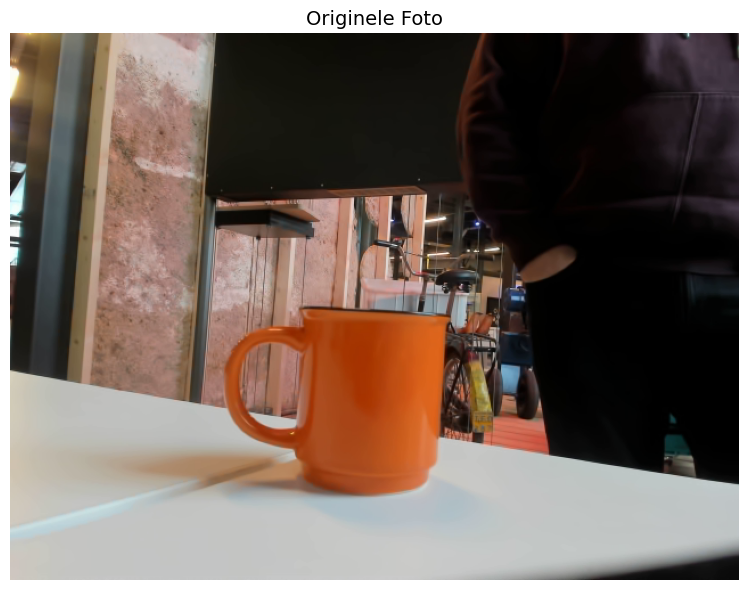

In [5]:
# OPTIONEEL: Verander dit nummer als je een andere camera wilt gebruiken
CAMERA_INDEX = 0  

# Open webcam en maak een foto
print("Bezig met foto maken...\n")

if sys.platform == 'win32':
    cap = cv2.VideoCapture(CAMERA_INDEX, cv2.CAP_DSHOW)
else:
    cap = cv2.VideoCapture(CAMERA_INDEX)

if not cap.isOpened():
    print("✗ Kan camera niet openen!")
else:
    # Lees een frame
    ret, frame = cap.read()
    cap.release()
    
    if ret:
        print("✓ Foto gemaakt!")
        print(f"   Grootte: {frame.shape[1]}x{frame.shape[0]} pixels\n")
        
        # Converteer voor weergave
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # Toon originele foto
        plt.figure(figsize=(10, 6))
        plt.imshow(frame_rgb)
        plt.title('Originele Foto', fontsize=14)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print("✗ Kan geen foto maken!")
        frame = None

### Nu laten we YOLO naar de foto kijken!

Dit is het spannende moment - wat herkent de AI?

In [6]:
if frame is not None:
    print("YOLO analyseert de foto...\n")
    
    # Run YOLO detectie
    # conf=0.5 betekent: toon alleen detecties met >50% zekerheid
    results = model(frame, conf=0.5)
    
    print("✓ Analyse compleet!\n")
    
    # Hoeveel objecten zijn gevonden?
    num_detections = len(results[0].boxes)
    print(f"Gevonden: {num_detections} object(en)\n")
    
    # Toon details van elke detectie
    if num_detections > 0:
        print("Details van gevonden objecten:")
        print("=" * 60)
        
        for i, box in enumerate(results[0].boxes):
            # Haal informatie op
            class_id = int(box.cls[0])
            class_name = model.names[class_id]
            confidence = float(box.conf[0])
            
            # Haal positie op (x1, y1, x2, y2)
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            
            print(f"\n{i+1}. {class_name.upper()}")
            print(f"   └─ Zekerheid: {confidence*100:.1f}%")
            print(f"   └─ Positie: ({int(x1)}, {int(y1)}) → ({int(x2)}, {int(y2)})")
            print(f"   └─ Grootte: {int(x2-x1)}x{int(y2-y1)} pixels")
        
        print("\n" + "=" * 60)
    else:
        print("Geen objecten gevonden met >50% zekerheid")
        print("   Probeer:")
        print("   - Meer licht")
        print("   - Camera anders richten")
        print("   - Objecten dichterbij")
else:
    print("✗ Geen foto beschikbaar om te analyseren")

YOLO analyseert de foto...


0: 480x640 1 person, 1 cup, 52.7ms
Speed: 2.0ms preprocess, 52.7ms inference, 5.2ms postprocess per image at shape (1, 3, 480, 640)
✓ Analyse compleet!

Gevonden: 2 object(en)

Details van gevonden objecten:

1. CUP
   └─ Zekerheid: 96.6%
   └─ Positie: (186, 239) → (386, 407)
   └─ Grootte: 199x167 pixels

2. PERSON
   └─ Zekerheid: 87.4%
   └─ Positie: (390, 0) → (639, 384)
   └─ Grootte: 249x384 pixels



### Toon de foto met detecties

Nu gaan we de foto tonen met vakjes rond de gevonden objecten:

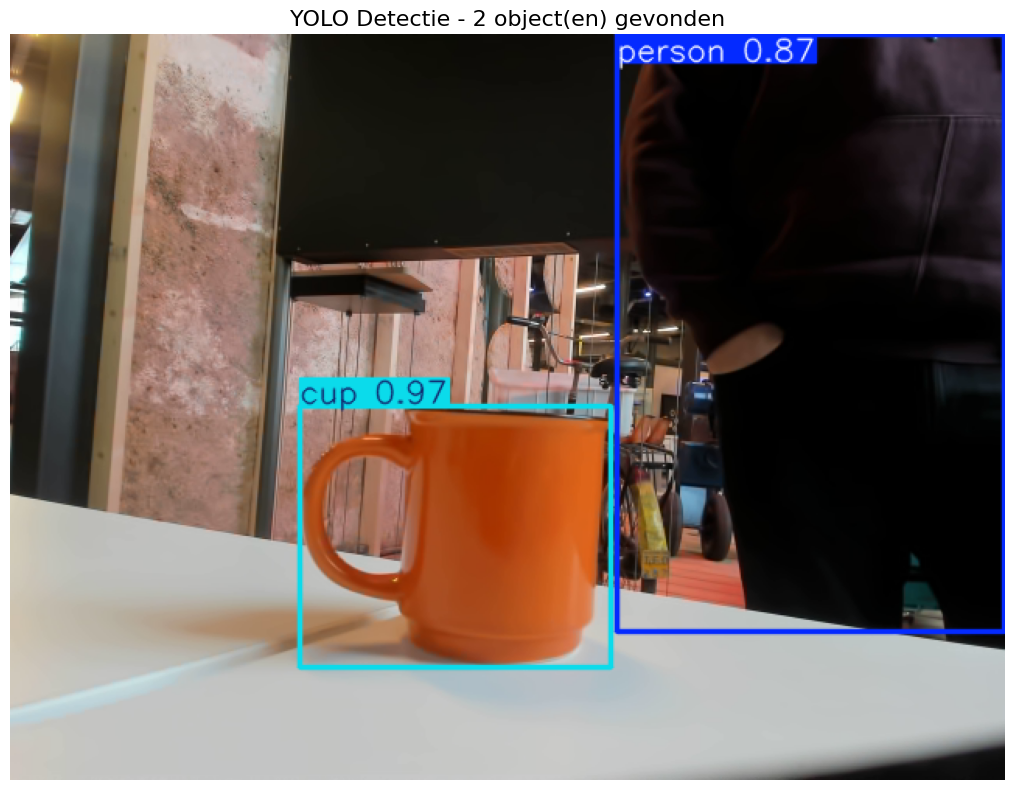


Kijk! YOLO heeft vakjes getekend rond de objecten!
   - Elke kleur is een ander soort object
   - Het percentage geeft de zekerheid aan


In [7]:
if frame is not None and num_detections > 0:
    # Plot de resultaten
    # results[0].plot() tekent automatisch vakjes en labels
    annotated_frame = results[0].plot()
    
    # Converteer BGR naar RGB voor correcte kleuren
    annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
    
    # Toon de foto met detecties
    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_frame_rgb)
    plt.title(f'YOLO Detectie - {num_detections} object(en) gevonden', fontsize=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    print("\nKijk! YOLO heeft vakjes getekend rond de objecten!")
    print("   - Elke kleur is een ander soort object")
    print("   - Het percentage geeft de zekerheid aan")

---

## Stap 4: Realtime Object Detectie

Nu gaan we het echt spannend maken - **realtime detectie**!

### Wat gebeurt er?

Het script zal:
1. Je webcam openen in een apart venster
2. Elk frame door YOLO laten analyseren
3. De detecties direct tonen
4. FPS (frames per second) bijhouden

### Hoe stoppen?

- Druk op **'q'** in het webcam venster
- Of wacht 30 seconden (automatische timeout)

**Let op**: Dit opent een nieuw venster buiten de notebook!

In [10]:
print("Starten realtime object detectie...\n")
print("Tips:")
print("   - Een nieuw venster opent zich")
print("   - Beweeg objecten voor de camera")
print("   - Druk 'q' in het venster om te stoppen")
print("   - Of wacht 30 seconden voor auto-stop\n")

# Open webcam
if sys.platform == 'win32':
    cap = cv2.VideoCapture(CAMERA_INDEX, cv2.CAP_DSHOW)
else:
    cap = cv2.VideoCapture(CAMERA_INDEX)

if not cap.isOpened():
    print("✗ Kan camera niet openen!")
else:
    print("✓ Camera geopend! Venster opent zich nu...\n")
    
    # FPS tracking
    frame_count = 0
    start_time = time.time()
    fps = 0
    
    # 30 seconden timeout
    timeout = 30
    
    while True:
        # Check timeout
        if time.time() - start_time > timeout:
            print(f"\nAutomatische stop na {timeout} seconden")
            break
        
        # Lees frame
        ret, frame = cap.read()
        if not ret:
            print("\n✗ Kan geen frame lezen!")
            break
        
        # Run YOLO detectie
        results = model(frame, conf=0.5, verbose=False)
        
        # Teken resultaten
        annotated_frame = results[0].plot()
        
        # Bereken FPS
        frame_count += 1
        if frame_count % 10 == 0:
            elapsed = time.time() - start_time
            fps = frame_count / elapsed
        
        # Voeg FPS toe aan beeld
        cv2.putText(
            annotated_frame,
            f"FPS: {fps:.1f}",
            (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.0,
            (0, 255, 0),
            2
        )
        
        # Toon het frame
        cv2.imshow('YOLO Realtime Detection - Druk Q om te stoppen', annotated_frame)
        
        # Stop bij 'q'
        if cv2.waitKey(1) & 0xFF == ord('q'):
            print("\nGestopt door gebruiker")
            break
    
    # Cleanup
    cap.release()
    cv2.destroyAllWindows()
    
    # Toon statistieken
    elapsed = time.time() - start_time
    print("\n" + "="*60)
    print("Sessie Statistieken:")
    print("="*60)
    print(f"   Tijd gedraaid: {elapsed:.1f} seconden")
    print(f"   Frames verwerkt: {frame_count}")
    print(f"   Gemiddelde FPS: {fps:.1f}")
    print("="*60)
    
    # FPS interpretatie
    print("\nFPS betekenis:")
    if fps > 20:
        print("   ✓ Uitstekend! Smooth realtime detectie")
    elif fps > 10:
        print("   ✓ Goed! Werkbaar voor de meeste toepassingen")
    else:
        print("   Langzaam - CPU heeft moeite met realtime verwerking")
        print("      Tip: Gebruik een kleinere resolutie of kleiner model")

Starten realtime object detectie...

Tips:
   - Een nieuw venster opent zich
   - Beweeg objecten voor de camera
   - Druk 'q' in het venster om te stoppen
   - Of wacht 30 seconden voor auto-stop

✓ Camera geopend! Venster opent zich nu...


Automatische stop na 30 seconden

Sessie Statistieken:
   Tijd gedraaid: 30.4 seconden
   Frames verwerkt: 893
   Gemiddelde FPS: 29.7

FPS betekenis:
   ✓ Uitstekend! Smooth realtime detectie


---

## Wat heb je nu gedaan en gezien?

In deze notebook heb je:
1. ✓ Gezien wat YOLO is en hoe het werkt
2. ✓ Een AI model geladen en gebruikt
3. ✓ De 80 objecten gezien die YOLO kan herkennen
4. ✓ Object detectie gedaan op een enkele foto
5. ✓ Detectie resultaten geanalyseerd (class, confidence, positie)
6. ✓ Realtime object detectie zien werken
7. ✓ FPS gemeten en begrepen wat dat betekent

**Belangrijk:** De code draaide al voor je - je hebt gezien HOE het werkt. In de volgende notebook ga je **zelf code schrijven**!

---

## Volgende Stap: Nu ga je ZELF programmeren!

Nu je weet hoe object detectie werkt, gaan we in de volgende notebook:

### Notebook 3: Object Counter (Interactief)

Daar ga je:
- **Zelf code schrijven** om objecten te tellen
- **Begrijpen** hoe je door detectie resultaten loopt
- **Tekst toevoegen** aan het beeld
- **Je eigen functionaliteit** bouwen

**Dát wordt het echte programmeerwerk - je gaat het echt maken!**

---

## Experimenteer Zelf!

Voordat je naar de volgende notebook gaat, probeer dit eens:

### Experiment 1: Verander de confidence threshold

Ga terug naar de cellen hierboven en verander `conf=0.5` naar:
- `conf=0.3` → Meer detecties (maar ook meer fouten)
- `conf=0.7` → Minder detecties (maar nauwkeuriger)

**Vraag jezelf af:** Wanneer wil je een lage threshold? Wanneer een hoge?

### Experiment 2: Verschillende objecten

Test met verschillende dingen voor de camera:
- Personen (ga staan, ga zitten)
- Laptop, telefoon
- Meubels (stoel, tafel)
- Je handen (worden soms als "person" gezien!)

**Let op:** Welke objecten worden makkelijk/moeilijk herkend?

### Experiment 3: Analyseer de FPS

Let op de FPS tijdens realtime detectie:
- Wat gebeurt er als je veel objecten in beeld hebt?
- Wordt het sneller met minder objecten?
- Wat is het verschil tussen een "lege" achtergrond en een drukke scene?

**Denk na:** Waarom zou FPS belangrijk zijn voor echte toepassingen?

---

## Tips voor in de notebook

**Handige shortcuts:**
- `Shift + Enter`: Voer cel uit en ga naar volgende
- `Ctrl + Enter`: Voer cel uit en blijf in dezelfde cel

**Als de realtime detectie vastloopt:**
- Druk op de stop knop (⬛) bovenaan
- Herstart de kernel als het niet reageert

---

### Klaar? Dan is het nu tijd om zelf te gaan programmeren in Notebook 3!